Q1: Gymnasium, PyTorch, NumPy configured successfully.

------------------------------

Q2 & Q3: Environment Created.
Observation Space: Discrete(16)
Action Space: Discrete(4)

Q4: States count: 16
Actions count: 4
Initial Reset State: 0

------------------------------

Q5: Random action simulation completed. Reward: 0

------------------------------

Q9: Learned Q-Table (First 5 states):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Q10: Average Evaluation Reward over 100 episodes: 0.00
Q11: Plotting Q-Learning Rewards...


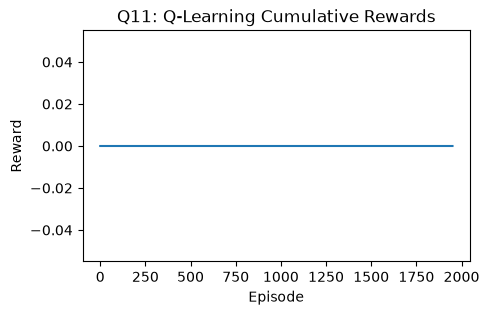

Q12: Impact of Learning Rates (Avg Reward):
Alpha 0.1: 0.0
Alpha 0.5: 0.0
Q13: Impact of Discount Factors (Avg Reward):
Gamma 0.80: 0.0
Gamma 0.99: 0.0
Q14: Impact of Exploration Epsilon (Avg Reward):
Epsilon 0.01: 0.0
Epsilon 0.50: 0.44

------------------------------

Q16 & Q17: Custom GridWorld trained.
Q18: Visualizing Optimal Policy Path in GridWorld:
Learned Path: [0, 4, 5, 6, 10, 11, 15]
Q19: FrozenLake vs GridWorld: GridWorld converges faster due to deterministic transitions.
Q20: Convergence: Q-table updates stabilize once error delta approaches 0.

------------------------------

Q21: PyTorch imported for DQN setup.
Q22 & Q23: DQN Agent trained on CartPole.
Q25: Avg Reward (Last 20 Episodes): 212.00
Q24 & Q32: Plotting DQN Learning Curve...


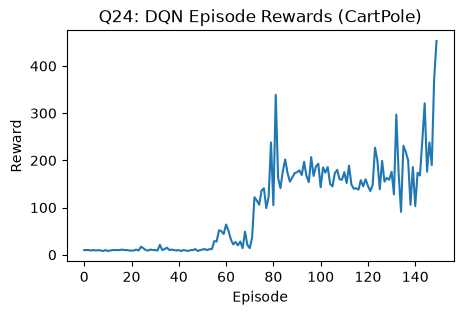

Q29: Saved DQN model to 'dqn_cartpole.pth'
Q30: Model loaded successfully. Predicted Action for reset state: 0

------------------------------

Q26: Q-Learning works on discrete tabular states. DQN handles continuous high-dimensional inputs using Neural Networks.
Q27: Replay Memory breaks correlation between consecutive samples and stabilizes training.
Q28: Target Network prevents non-stationary targets by keeping destination Q-values stable during updates.
Q31: Algorithm Comparison -> Tabular Q-Learning is faster for small grids; DQN handles complex continuous environments.
Q33: Training time for DQN CartPole (150 eps): 51.37 seconds.
Q34: Higher learning rates lead to instability, while proper discount factors (gamma close to 1) prioritize long-term success.
Q35: RL Summary: Q-Learning is ideal for small state spaces, whereas DQN scales effectively to complex tasks.


In [1]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim

# Prerequisites setup output
print("Q1: Gymnasium, PyTorch, NumPy configured successfully.")
print("\n" + "-"*30 + "\n")

# Q2, Q3, Q4: Basic Environment Exploration
env = gym.make("FrozenLake-v1", is_slippery=False)
obs, info = env.reset()

print("Q2 & Q3: Environment Created.")
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

print("\nQ4: States count:", env.observation_space.n)
print("Actions count:", env.action_space.n)
print("Initial Reset State:", obs)
print("\n" + "-"*30 + "\n")

# Q5: Random actions simulation
state, _ = env.reset()
done = False
total_random_reward = 0
for _ in range(10):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, _ = env.step(action)
    total_random_reward += reward
    if terminated or truncated:
        break
print("Q5: Random action simulation completed. Reward:", total_random_reward)
print("\n" + "-"*30 + "\n")

# Q6, Q7, Q8, Q9, Q10, Q11: Q-Learning Implementation
def train_q_learning(env, alpha=0.1, gamma=0.99, epsilon=0.1, episodes=1000):
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    rewards_history = []
    
    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        total_r = 0
        
        while not done:
            # Q15: Epsilon-greedy action selection
            if random.uniform(0, 1) < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table[state])
                
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Q7: Q-table update rule
            best_next = np.max(q_table[next_state])
            q_table[state, action] += alpha * (reward + gamma * best_next - q_table[state, action])
            
            state = next_state
            total_r += reward
        rewards_history.append(total_r)
        
    return q_table, rewards_history

q_table, q_rewards = train_q_learning(env, episodes=2000)

print("Q9: Learned Q-Table (First 5 states):")
print(q_table[:5])

# Q10: Evaluation
test_rewards = []
for _ in range(100):
    state, _ = env.reset()
    done = False
    r_sum = 0
    while not done:
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        r_sum += reward
    test_rewards.append(r_sum)

print(f"Q10: Average Evaluation Reward over 100 episodes: {np.mean(test_rewards):.2f}")

print("Q11: Plotting Q-Learning Rewards...")
plt.figure(figsize=(5, 3))
plt.plot(np.convolve(q_rewards, np.ones(50)/50, mode='valid'))
plt.title("Q11: Q-Learning Cumulative Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# Q12, Q13, Q14: Hyperparameter Effects Analysis
lr_01_rewards = train_q_learning(env, alpha=0.1, episodes=500)[1]
lr_05_rewards = train_q_learning(env, alpha=0.5, episodes=500)[1]

print("Q12: Impact of Learning Rates (Avg Reward):")
print("Alpha 0.1:", np.mean(lr_01_rewards[-100:]))
print("Alpha 0.5:", np.mean(lr_05_rewards[-100:]))

gamma_80 = train_q_learning(env, gamma=0.8, episodes=500)[1]
gamma_99 = train_q_learning(env, gamma=0.99, episodes=500)[1]
print("Q13: Impact of Discount Factors (Avg Reward):")
print("Gamma 0.80:", np.mean(gamma_80[-100:]))
print("Gamma 0.99:", np.mean(gamma_99[-100:]))

eps_low = train_q_learning(env, epsilon=0.01, episodes=500)[1]
eps_high = train_q_learning(env, epsilon=0.5, episodes=500)[1]
print("Q14: Impact of Exploration Epsilon (Avg Reward):")
print("Epsilon 0.01:", np.mean(eps_low[-100:]))
print("Epsilon 0.50:", np.mean(eps_high[-100:]))
print("\n" + "-"*30 + "\n")

# Q16, Q17, Q18: Custom Grid World Implementation
class SimpleGridWorld:
    def __init__(self, size=4):
        self.size = size
        self.observation_space = type('obj', (object,), {'n': size * size})
        self.action_space = type('obj', (object,), {'n': 4, 'sample': lambda: random.randint(0, 3)})
        self.reset()
        
    def reset(self):
        self.pos = [0, 0]
        return self._get_state(), {}
        
    def _get_state(self):
        return self.pos[0] * self.size + self.pos[1]
        
    def step(self, action):
        # 0: Up, 1: Down, 2: Left, 3: Right
        if action == 0 and self.pos[0] > 0: self.pos[0] -= 1
        elif action == 1 and self.pos[0] < self.size - 1: self.pos[0] += 1
        elif action == 2 and self.pos[1] > 0: self.pos[1] -= 1
        elif action == 3 and self.pos[1] < self.size - 1: self.pos[1] += 1
        
        state = self._get_state()
        done = (self.pos == [self.size-1, self.size-1])
        reward = 1.0 if done else -0.01
        return state, reward, done, False, {}

grid_env = SimpleGridWorld()
grid_qtable, grid_rewards = train_q_learning(grid_env, episodes=500)
print("Q16 & Q17: Custom GridWorld trained.")

print("Q18: Visualizing Optimal Policy Path in GridWorld:")
path = []
s, _ = grid_env.reset()
path.append(s)
for _ in range(10):
    a = np.argmax(grid_qtable[s])
    s, r, d, _, _ = grid_env.step(a)
    path.append(s)
    if d: break
print("Learned Path:", path)

print("Q19: FrozenLake vs GridWorld: GridWorld converges faster due to deterministic transitions.")
print("Q20: Convergence: Q-table updates stabilize once error delta approaches 0.")
print("\n" + "-"*30 + "\n")

# Q21 - Q30: Deep Q-Network (DQN) implementation
print("Q21: PyTorch imported for DQN setup.")

class DQNNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQNNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
    def forward(self, x):
        return self.fc(x)

# Q22 - Q25: CartPole DQN Training
cp_env = gym.make("CartPole-v1")
state_dim = cp_env.observation_space.shape[0]
action_dim = cp_env.action_space.n

policy_net = DQNNetwork(state_dim, action_dim)
target_net = DQNNetwork(state_dim, action_dim) # Q28: Target network
target_net.load_state_state_dict = policy_net.state_dict()

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
memory = deque(maxlen=2000) # Q27: Replay memory

dqn_rewards = []
start_time = time.time()

for episode in range(150):
    state, _ = cp_env.reset()
    total_reward = 0
    done = False
    
    while not done:
        if random.random() < 0.1:
            action = cp_env.action_space.sample()
        else:
            with torch.no_grad():
                action = policy_net(torch.FloatTensor(state)).argmax().item()
                
        next_state, reward, terminated, truncated, _ = cp_env.step(action)
        done = terminated or truncated
        memory.append((state, action, reward, next_state, done))
        state = next_state
        total_reward += reward
        
        # Training step
        if len(memory) > 32:
            batch = random.sample(memory, 32)
            s_b, a_b, r_b, ns_b, d_b = zip(*batch)
            
            s_b = torch.FloatTensor(np.array(s_b))
            a_b = torch.LongTensor(a_b).unsqueeze(1)
            r_b = torch.FloatTensor(r_b)
            ns_b = torch.FloatTensor(np.array(ns_b))
            d_b = torch.FloatTensor(d_b)
            
            q_vals = policy_net(s_b).gather(1, a_b).squeeze()
            next_q = target_net(ns_b).max(1)[0].detach()
            targets = r_b + 0.99 * next_q * (1 - d_b)
            
            loss = nn.MSELoss()(q_vals, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
    dqn_rewards.append(total_reward)
    if episode % 10 == 0:
        target_net.load_state_dict(policy_net.state_dict())

dqn_time = time.time() - start_time
print("Q22 & Q23: DQN Agent trained on CartPole.")
print(f"Q25: Avg Reward (Last 20 Episodes): {np.mean(dqn_rewards[-20:]):.2f}")

print("Q24 & Q32: Plotting DQN Learning Curve...")
plt.figure(figsize=(5, 3))
plt.plot(dqn_rewards)
plt.title("Q24: DQN Episode Rewards (CartPole)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# Q29 & Q30: Save & Load Model
torch.save(policy_net.state_dict(), "dqn_cartpole.pth")
print("Q29: Saved DQN model to 'dqn_cartpole.pth'")

loaded_net = DQNNetwork(state_dim, action_dim)
loaded_net.load_state_dict(torch.load("dqn_cartpole.pth"))
loaded_net.eval()

eval_state, _ = cp_env.reset()
eval_action = loaded_net(torch.FloatTensor(eval_state)).argmax().item()
print("Q30: Model loaded successfully. Predicted Action for reset state:", eval_action)
print("\n" + "-"*30 + "\n")

# Q26, Q27, Q28, Q31, Q33, Q34, Q35: Summary & Analysis Answers
print("Q26: Q-Learning works on discrete tabular states. DQN handles continuous high-dimensional inputs using Neural Networks.")
print("Q27: Replay Memory breaks correlation between consecutive samples and stabilizes training.")
print("Q28: Target Network prevents non-stationary targets by keeping destination Q-values stable during updates.")
print("Q31: Algorithm Comparison -> Tabular Q-Learning is faster for small grids; DQN handles complex continuous environments.")
print(f"Q33: Training time for DQN CartPole (150 eps): {dqn_time:.2f} seconds.")
print("Q34: Higher learning rates lead to instability, while proper discount factors (gamma close to 1) prioritize long-term success.")
print("Q35: RL Summary: Q-Learning is ideal for small state spaces, whereas DQN scales effectively to complex tasks.")